In [2]:
!wget https://asset.coecore.com/faidi/IrisSpecies.csv

--2026-02-27 15:23:49--  https://asset.coecore.com/faidi/IrisSpecies.csv
Resolving asset.coecore.com (asset.coecore.com)... 203.158.183.51
Connecting to asset.coecore.com (asset.coecore.com)|203.158.183.51|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5107 (5.0K) [application/octet-stream]
Saving to: 'IrisSpecies.csv.8'

     0K ....                                                  100% 1.59G=0s

2026-02-27 15:23:49 (1.59 GB/s) - 'IrisSpecies.csv.8' saved [5107/5107]



#IMPORT LIB

In [3]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df_iris = pd.read_csv("./IrisSpecies.csv")

In [5]:
df_iris.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
df_iris.shape

(150, 6)

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [8]:
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [9]:
df_iris["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [10]:
df_iris.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

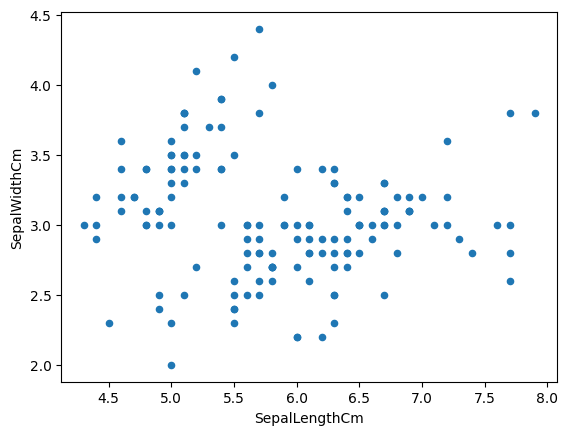

In [11]:
df_iris.plot(kind="scatter", x="SepalLengthCm", y="SepalWidthCm")

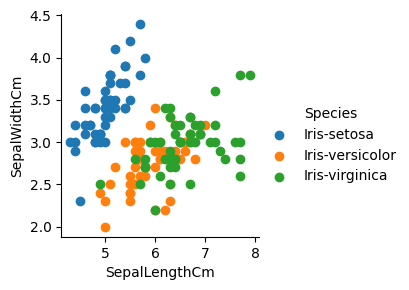

In [12]:
sns.FacetGrid(df_iris, hue="Species") \
    .map(plt.scatter, "SepalLengthCm", "SepalWidthCm") \
    .add_legend()

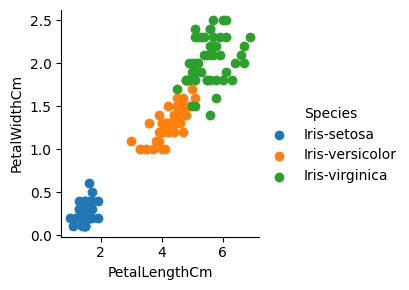

In [13]:
sns.FacetGrid(df_iris, hue="Species") \
.map(plt.scatter, "PetalLengthCm", "PetalWidthCm") \
.add_legend()

C:\Users\Lab18302-00\AppData\Local\Temp\ipykernel_19312\2123192420.py:2: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  ax = sns.stripplot(data=df_iris, x="Species", y="PetalLengthCm", jitter=True, edgecolor="gray")


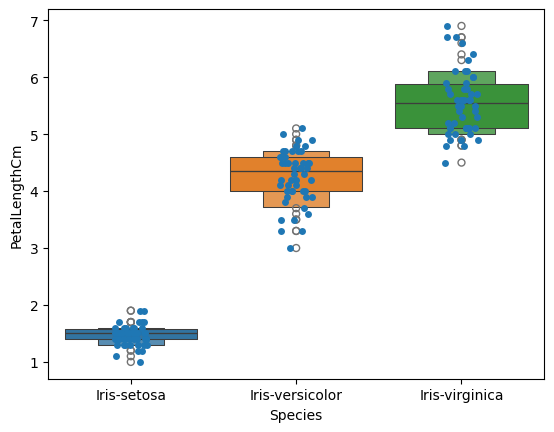

In [14]:
sns.boxenplot(data=df_iris, x="Species", hue="Species", y="PetalLengthCm")
ax = sns.stripplot(data=df_iris, x="Species", y="PetalLengthCm", jitter=True, edgecolor="gray")

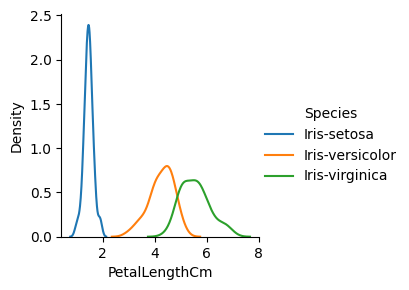

In [15]:
sns.FacetGrid(data=df_iris, hue="Species") \
.map(sns.kdeplot, "PetalLengthCm") \
.add_legend()

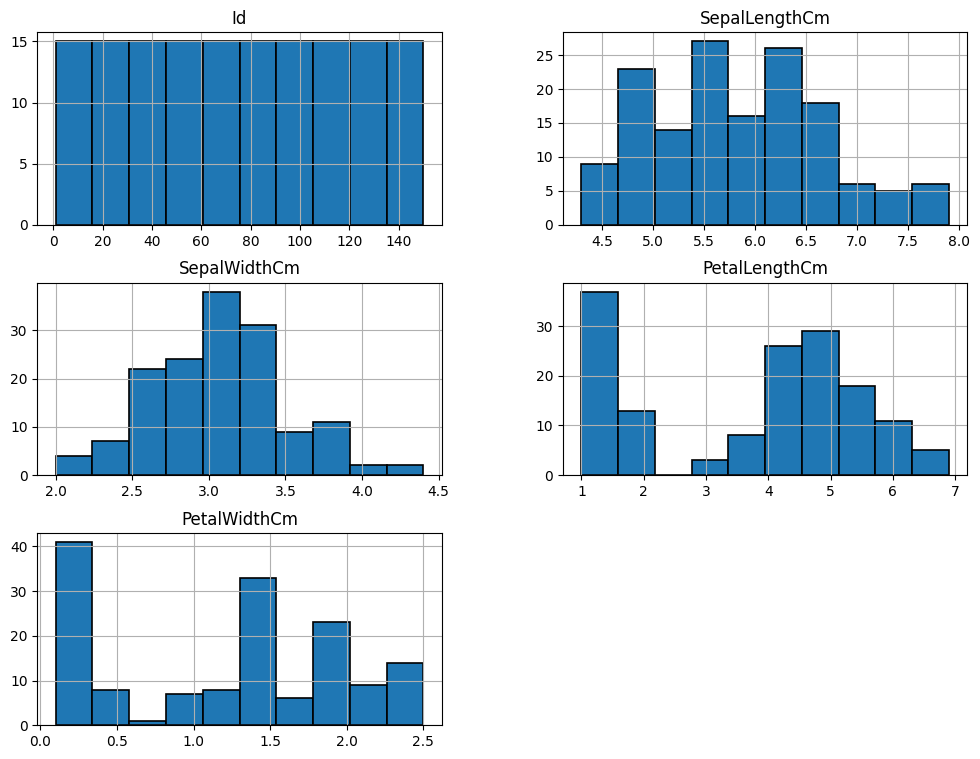

In [16]:
df_iris.hist(edgecolor='black', linewidth=1.2)# Creates histograms for each column in the DataFrame 'df_iris'
fig=plt.gcf() # Gets the current figure
fig.set_size_inches(12,9) # Sets the size of the figure to 12 inches by 6 inches
plt.show() # Displays the plot


In [17]:
df_iris.drop("Id", axis=1, inplace=True)

In [18]:
df_iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


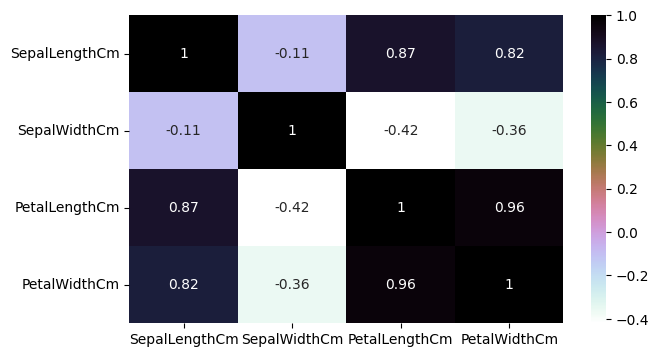

In [19]:
plt.figure(figsize=(7,4))
sns.heatmap(df_iris[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]].corr(),annot=True,cmap='cubehelix_r') #draws heatmap with input as the correlation matrix calculted by(iris.corr())
plt.show()


Import sk-learn metrices


Import train test split

In [20]:
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [21]:
train, test = train_test_split(df_iris, test_size= 0.3, random_state=42, stratify=df_iris["Species"])
print(train.shape)
print(test.shape)
print(type(train))
print(type(test))

(105, 5)
(45, 5)
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [22]:
train["Species"].value_counts()

Species
Iris-versicolor    35
Iris-setosa        35
Iris-virginica     35
Name: count, dtype: int64

In [23]:
test["Species"].value_counts()

Species
Iris-virginica     15
Iris-versicolor    15
Iris-setosa        15
Name: count, dtype: int64

In [24]:
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [25]:

train, test = train_test_split(df_iris, test_size= 0.3)#random_state=42, stratify=df_iris["Species"]

print(train.shape)
print(test.shape)
print(type(train))
print(type(test))

(105, 5)
(45, 5)
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [26]:
train = train.sample(frac=1).reset_index(drop=True)
test = test.reset_index(drop=True)

In [27]:
train_x = train[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
train_y = train.Species
test_x = test[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
test_y = test.Species

In [28]:
train.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,4.6,3.2,1.4,0.2,Iris-setosa
1,5.6,3.0,4.5,1.5,Iris-versicolor


In [29]:
from sklearn.linear_model import LogisticRegression 
model_logisregress = LogisticRegression() 
model_logisregress.fit(train_x, train_y) 
prediction=model_logisregress.predict(test_x) 
print('The accuracy of the Logistic Regression is', metrics.accuracy_score(prediction, test_y))



The accuracy of the Logistic Regression is 0.9555555555555556


In [30]:
# Confusion Matrix Report
TP = 0
FP = 0
for i in test_y.index:
    print(f'Target = {test_y[i]} \t\t AI_Precicted {prediction[i]}', end='')
    if test_y[i] != prediction[i]:
        FP += 1
        print(" >>>> Error", end='')
    else:
        TP += 1
        print(" >>>> Correct", end='')
    print(f" (TP={TP}, FP={FP})")
print(f'TP = {TP}, FP = {FP}')
# print accuracy
print(f'Accuracy = {TP/(TP+FP)}')
# print accuracy in percentage
print(f'Accuracy = {TP/(TP+FP)*100}%')

Target = Iris-virginica 		 AI_Precicted Iris-virginica >>>> Correct (TP=1, FP=0)
Target = Iris-versicolor 		 AI_Precicted Iris-versicolor >>>> Correct (TP=2, FP=0)
Target = Iris-virginica 		 AI_Precicted Iris-virginica >>>> Correct (TP=3, FP=0)
Target = Iris-setosa 		 AI_Precicted Iris-setosa >>>> Correct (TP=4, FP=0)
Target = Iris-setosa 		 AI_Precicted Iris-setosa >>>> Correct (TP=5, FP=0)
Target = Iris-virginica 		 AI_Precicted Iris-virginica >>>> Correct (TP=6, FP=0)
Target = Iris-versicolor 		 AI_Precicted Iris-versicolor >>>> Correct (TP=7, FP=0)
Target = Iris-virginica 		 AI_Precicted Iris-virginica >>>> Correct (TP=8, FP=0)
Target = Iris-versicolor 		 AI_Precicted Iris-versicolor >>>> Correct (TP=9, FP=0)
Target = Iris-versicolor 		 AI_Precicted Iris-versicolor >>>> Correct (TP=10, FP=0)
Target = Iris-setosa 		 AI_Precicted Iris-setosa >>>> Correct (TP=11, FP=0)
Target = Iris-versicolor 		 AI_Precicted Iris-versicolor >>>> Correct (TP=12, FP=0)
Target = Iris-versicolor 		 AI_Pr

In [31]:
from sklearn.tree import DecisionTreeClassifier #for using Decision Tree Algoithm
model_dt = DecisionTreeClassifier()
model_dt.fit(train_x,train_y)
prediction = model_dt.predict(test_x)
print('The accuracy of the Decision Tree is',metrics.accuracy_score(prediction,test_y))

The accuracy of the Decision Tree is 0.9555555555555556


In [32]:
from sklearn.neighbors import KNeighborsClassifier  # for K nearest neighbours
model_knn = KNeighborsClassifier(n_neighbors=3) #this examines 3 neighbours for putting the new data into a class
model_knn.fit(train_x,train_y)
prediction=model_knn.predict(test_x)
print('The accuracy of the KNN is',metrics.accuracy_score(prediction,test_y))

The accuracy of the KNN is 0.9555555555555556


In [33]:
from sklearn import svm  #for Support Vector Machine (SVM) Algorithm
model_svm = svm.SVC() #select the algorithm
model_svm.fit(train_x,train_y) # we train the algorithm with the training data and the training output
prediction = model_svm.predict(test_x) #now we pass the testing data to the trained algorithm
print('The accuracy of the SVM is ',metrics.accuracy_score(prediction,test_y))#now we check the accuracy of the algorithm.
#we pass the predicted output by the model and the actual output



The accuracy of the SVM is  0.9555555555555556


In [34]:
from sklearn.ensemble import RandomForestClassifier #for Random Forest Algorithm
model_rf=RandomForestClassifier(n_estimators=100)# a simple random forest model
model_rf.fit(train_x,train_y)# now we fit the model
prediction=model_rf.predict(test_x)# predict the test data
print('The accuracy of the Random Forests is',metrics.accuracy_score(prediction,test_y))

The accuracy of the Random Forests is 0.9555555555555556


In [35]:
## Importing required libraries
from sklearn.neural_network import MLPClassifier
# from sklearn.preprocessing import LabelEncoder # don't use now
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
import numpy as np

onehot_encoder = OneHotEncoder()

# normalize minmax ---> (X-min_x)/(max_x - min_x)
scaler = MinMaxScaler()

onehot_train_y = onehot_encoder.fit_transform(
    train_y.to_numpy().reshape(-1,1)
).toarray()

onehot_test_y = onehot_encoder.transform(
    test_y.to_numpy().reshape(-1,1)
).toarray()

ScaledData_train_x = scaler.fit_transform(train_x.astype(np.float64))
ScaledData_test_x = scaler.transform(test_x.astype(np.float64))

# บันทึก pickle ไว้ใช้งานในอนาคต
import pickle
# บันทึก
with open('scaler_train.pkl', 'wb') as f:
   pickle.dump(scaler, f)

with open('scaler_train.pkl', 'rb') as f:
   newload_scaler = pickle.load(f)

print(f"min={scaler.data_min_},max={scaler.data_max_}")
# print the first row of the normal data
print(f"train_X (before normalize): \n{train_x.iloc[0,:]}")
print(f"\nNormallizedData:{ScaledData_train_x[0,:]}")

model_mlp = MLPClassifier(
    hidden_layer_sizes=(20,10),
    activation="relu",
    max_iter=1000,
    alpha=1e-4,
    early_stopping=False,
    solver='adam',
    verbose=10,
    random_state=1,
    learning_rate_init=.005
)

model_mlp.fit(ScaledData_train_x, onehot_train_y)

prediction = model_mlp.predict(ScaledData_test_x)

prediction_labels = np.argmax(prediction, axis=1)
true_labels = np.argmax(onehot_test_y, axis=1)

print('The accuracy of the ANN is',
      metrics.accuracy_score(true_labels, prediction_labels))

min=[4.4 2.2 1.  0.1],max=[7.9 4.4 6.7 2.5]
train_X (before normalize): 
SepalLengthCm    4.6
SepalWidthCm     3.2
PetalLengthCm    1.4
PetalWidthCm     0.2
Name: 0, dtype: float64

NormallizedData:[0.05714286 0.45454545 0.07017544 0.04166667]
Iteration 1, loss = 2.13833742
Iteration 2, loss = 2.10281554
Iteration 3, loss = 2.06942816
Iteration 4, loss = 2.03944153
Iteration 5, loss = 2.01171687
Iteration 6, loss = 1.98518151
Iteration 7, loss = 1.95980263
Iteration 8, loss = 1.93576838
Iteration 9, loss = 1.91239767
Iteration 10, loss = 1.88902130
Iteration 11, loss = 1.86520222
Iteration 12, loss = 1.84108159
Iteration 13, loss = 1.81644117
Iteration 14, loss = 1.79086153
Iteration 15, loss = 1.76465649
Iteration 16, loss = 1.73903384
Iteration 17, loss = 1.71466492
Iteration 18, loss = 1.69066600
Iteration 19, loss = 1.66640512
Iteration 20, loss = 1.64187171
Iteration 21, loss = 1.61756572
Iteration 22, loss = 1.59404248
Iteration 23, loss = 1.57071688
Iteration 24, loss = 1.546835

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
   'hidden_layer_sizes': [(5,), (10,), (10, 5), (20, 10)],
   'alpha':              [1e-4, 1e-3, 1e-2],
   'learning_rate_init': [0.001, 0.005, 0.01],
   'activation':         ['relu', 'tanh'],
   'solver': ['sgd','adam']
}

mlp = MLPClassifier(max_iter=1000, solver='adam', random_state=1)

grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(ScaledData_train_x, onehot_train_y)

print("Best params:", grid_search.best_params_)
print("Best CV acc:", grid_search.best_score_)

# ใช้ model ที่ดีที่สุด
best_mlp = grid_search.best_estimator_
prediction = best_mlp.predict(ScaledData_test_x)
print("Test acc:", metrics.accuracy_score(prediction, onehot_test_y))




Fitting 5 folds for each of 144 candidates, totalling 720 fits


Best params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best CV acc: 0.9619047619047618
Test acc: 0.9555555555555556


In [37]:
from sklearn.preprocessing import LabelEncoder
Labeler = LabelEncoder()
Labeler.fit(train_y)  # fit เพื่อใช้กับ ANN เท่านั้น

one_flower = np.array([5.1, 3.5, 1.4, 0.2]).reshape(1, -1)
print(f"classes_mapper: {Labeler.classes_}")

# ✅ โมเดลเหล่านี้คืนค่า string label โดยตรง ไม่ต้อง inverse_transform
logisregress_prediction = model_logisregress.predict(one_flower)
print(f'Logistic Regression predicts: {logisregress_prediction[0]}')

dt_prediction = model_dt.predict(one_flower)
print(f'Decision Tree predicts: {dt_prediction[0]}')

knn_prediction = model_knn.predict(one_flower)
print(f'KNN predicts: {knn_prediction[0]}')

svm_prediction = model_svm.predict(one_flower)
print(f'SVM predicts: {svm_prediction[0]}')

rf_prediction = model_rf.predict(one_flower)
print(f'Random Forest predicts: {rf_prediction[0]}')

# ✅ ANN เท่านั้นที่ต้องแปลง OneHot → index → string
one_flower_scaled = scaler.transform(one_flower)
ann_prediction = model_mlp.predict(one_flower_scaled)
print(ann_prediction)
ann_class_index = np.argmax(ann_prediction, axis=1)          # OneHot → index
ann_label = Labeler.inverse_transform(ann_class_index)       # index → string
print(f'ANN predicts: {ann_label}')



classes_mapper: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Logistic Regression predicts: Iris-setosa
Decision Tree predicts: Iris-setosa
KNN predicts: Iris-setosa
SVM predicts: Iris-setosa
Random Forest predicts: Iris-setosa
[[1 0 0]]
ANN predicts: ['Iris-setosa']


d:\ml 001\venv-ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
d:\ml 001\venv-ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\ml 001\venv-ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
d:\ml 001\venv-ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
d:\ml 001\venv-ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\ml 001\venv-ml\Lib\site-packages\sklearn\utils\valid

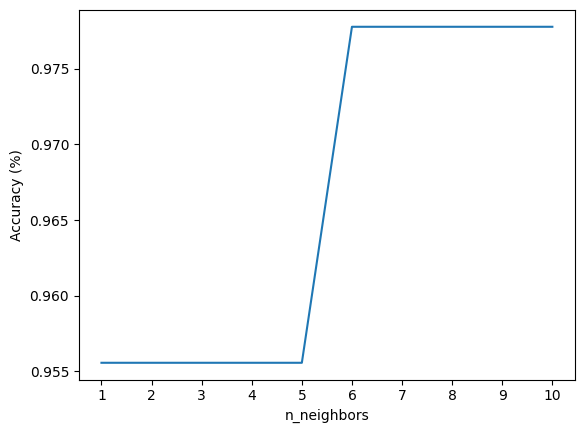

In [38]:
a_index=list(range(1,11))
a=[]
x=[1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(train_x,train_y)
    prediction=model.predict(test_x)
    a.append(metrics.accuracy_score(prediction,test_y))
# convert a to a numpy array
a = np.array(a)
plt.plot(a_index, a)
plt.xticks(x)
# Add axis labels
plt.xlabel("n_neighbors")  # X-axis title
plt.ylabel("Accuracy (%)")  # Y-axis title
# Show the plot
plt.show()



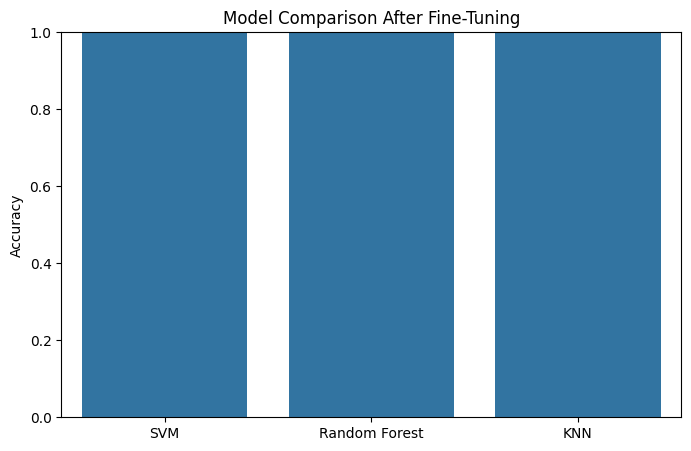

Best SVM Params: {'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kernel': 'poly'}
Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best KNN Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =======================
# 1) SVM
# =======================
svm = SVC()

param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3]
}

grid_svm = GridSearchCV(svm, param_svm, cv=5)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

# =======================
# 2) Random Forest
# =======================
rf = RandomForestClassifier()

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# =======================
# 3) KNN
# =======================
knn = KNeighborsClassifier()

param_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn, param_knn, cv=5)
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

# =======================
# Plot Comparison
# =======================
models = ['SVM', 'Random Forest', 'KNN']
accuracies = [acc_svm, acc_rf, acc_knn]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)
plt.title("Model Comparison After Fine-Tuning")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

print("Best SVM Params:", grid_svm.best_params_)
print("Best RF Params:", grid_rf.best_params_)
print("Best KNN Params:", grid_knn.best_params_)